# Week 5 — Error mitigation: M3 + ZNE (layered)

Closing the gap between the **simulated noisy** ratio (~0.9339) and the **ideal** (~0.9417), and explaining per channel why each technique does or doesn't help. Week 3 measured **0.910** on hardware — a 3.40pp gap, ~4x the sim's 0.78pp, because the real heavy-hex circuit needs SWAP routing that inflates the gate channel beyond what the all-to-all sim assumed.

**Two complementary techniques, not a choice:**
- **M3** inverts the readout assignment matrix. Attacks the *readout* channel only (your largest, 0.42pp in sim). Blind to gate/decoherence error.
- **ZNE** amplifies gate noise (circuit folding) and extrapolates to zero. Attacks the *gate* channel. Blind to readout (readout doesn't scale with folding).

**Pipeline order:** M3 cleans the counts first, then ZNE extrapolates the M3-corrected energy. Validate in sim (known ground truth), then one hardware run.

## Section 0 — Environment

In [1]:
# !pip install qiskit qiskit-aer mthree mitiq ply qiskit-ibm-runtime matplotlib
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error
import mthree
from mitiq import zne
from mitiq.zne.inference import LinearFactory, RichardsonFactory
from mitiq.zne.scaling import fold_global
np.set_printoptions(precision=4, suppress=True)

## Section 1 — Plug in your Week 4 objects

Set `USE_TOY = False` and provide your real Week 4 objects in the marked block. With `USE_TOY = True` the notebook runs standalone on a 4-asset QUBO so you can confirm the pipeline before wiring in the real problem.

In [2]:
RUN_HARDWARE = False  # flip True only for the final hardware run
USE_TOY       = False  # True = self-contained toy; False = your Week 4 objects
SHOTS         = 40000
SCALE_FACTORS = [1, 2, 3]    # noise scales for ZNE
ZNE_AVERAGES  = 4             # repeats per scale to suppress shot-noise variance

# ---------- WIRE IN YOUR WEEK 4 OBJECTS WHEN USE_TOY = False ----------
#   n_qubits        : int
#   qaoa_ansatz     : QuantumCircuit, optimal angles ALREADY BOUND, NO measurements
#   noise_model     : your synthetic Heron NoiseModel
#   physical_qubits : measured qubits (sim: list(range(n_qubits)); hardware: transpiled layout)
#   cost_bitstring(bits)->float : QUBO cost of a little-endian bitstring (lower = better)
#   approx_ratio(energy)->float : your Week 4 normalisation (ideal target ~0.9417)
# ---------------------------------------------------------------------

if USE_TOY:
    np.random.seed(7); n_qubits = 4
    _A = np.random.randn(n_qubits, n_qubits)
    _Q = (_A + _A.T)/2 + np.diag(np.random.randn(n_qubits))
    def cost_bitstring(bits):
        x = np.array([int(b) for b in bits[::-1]]); return float(x @ _Q @ x)
    _all = [cost_bitstring(format(i, f'0{n_qubits}b')) for i in range(2**n_qubits)]
    _Cmin, _Cmax = min(_all), max(_all)
    def approx_ratio(energy): return (energy - _Cmax) / (_Cmin - _Cmax)
    noise_model = NoiseModel(); _pro = 0.025
    _ro = ReadoutError([[1-_pro, _pro],[_pro, 1-_pro]])
    for q in range(n_qubits): noise_model.add_readout_error(_ro, [q])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.012, 2), ['cx'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.0012, 1), ['rx','rz','h'])
    physical_qubits = list(range(n_qubits))
    _h = np.zeros(n_qubits); _J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(n_qubits):
            if i == j: _h[i] += -0.5*_Q[i,i]
            else: _J[i,j] += 0.25*_Q[i,j]; _h[i] += -0.25*_Q[i,j]
    _g, _b = 0.571, 2.285
    qaoa_ansatz = QuantumCircuit(n_qubits); qaoa_ansatz.h(range(n_qubits))
    for i in range(n_qubits):
        if abs(_h[i]) > 1e-9: qaoa_ansatz.rz(2*_g*_h[i], i)
    for i in range(n_qubits):
        for j in range(i+1, n_qubits):
            _Jij = _J[i,j] + _J[j,i]
            if abs(_Jij) > 1e-9:
                qaoa_ansatz.cx(i, j); qaoa_ansatz.rz(2*_g*_Jij, j); qaoa_ansatz.cx(i, j)
    for i in range(n_qubits): qaoa_ansatz.rx(2*_b, i)
else:
    import sys, os
    if os.path.abspath('..') not in sys.path:
        sys.path.append(os.path.abspath('..'))
    # make src/ importable from notebooks/
    import numpy as np
    from qiskit import transpile
    from qiskit.quantum_info import SparsePauliOp
    from qiskit.transpiler.passes import RemoveBarriers
    from src.qaoa import qaoa_ansatz as make_qaoa_ansatz
    from src.noise_model import synthetic_heron_noise_model

    _d = np.load('../artifacts/week4_state.npz', allow_pickle=True)
    hamiltonian    = SparsePauliOp([str(x) for x in _d['pauli_labels']], _d['coeffs'])
    optimal_params = _d['optimal_params']           # [gamma, beta] at p=1
    n_qubits       = hamiltonian.num_qubits

    _param  = make_qaoa_ansatz(hamiltonian, p=1)
    _native = transpile(_param, basis_gates=['sx', 'rz', 'cz'], optimization_level=1)
    _native = RemoveBarriers()(_native)
    qaoa_ansatz = _native.assign_parameters(optimal_params)

    _labels = hamiltonian.paulis.to_labels()
    _coeffs = hamiltonian.coeffs.real
    def _diag_energy(bits):
        b = bits[::-1]; e = 0.0
        for _lab, _c in zip(_labels, _coeffs):
            L = _lab[::-1]; val = 1; ok = True
            for q, P in enumerate(L):
                if P == 'Z':    val *= 1 if b[q] == '0' else -1
                elif P in 'XY': ok = False; break
            if ok: e += _c * val
        return e
    _spectrum = {format(i, f'0{n_qubits}b'): _diag_energy(format(i, f'0{n_qubits}b'))
                 for i in range(2 ** n_qubits)}
    _ground_energy, _max_energy = min(_spectrum.values()), max(_spectrum.values())
    def cost_bitstring(bits): return _spectrum[bits]
    def approx_ratio(energy):  return (_max_energy - energy) / (_max_energy - _ground_energy)

    noise_model     = synthetic_heron_noise_model(n_qubits=n_qubits)
    physical_qubits = list(range(n_qubits))
    print(f"loaded Week 4 state | ground bitstring = {min(_spectrum, key=_spectrum.get)} (expect 00001111)")

assert qaoa_ansatz.num_clbits == 0, "qaoa_ansatz must have NO measurements (ZNE folds the unitary)"
_2q = sum(1 for ci in qaoa_ansatz.data if ci.operation.num_qubits == 2)
print(f"n_qubits={n_qubits}  depth={qaoa_ansatz.depth()}  2q gates={_2q}")

loaded Week 4 state | ground bitstring = 00001111 (expect 00001111)
n_qubits=8  depth=132  2q gates=56


In [3]:
ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise_model)

def counts_to_energy(counts):
    tot = sum(counts.values())
    return sum(cost_bitstring(b)*c for b, c in counts.items()) / tot

def run_counts(circ, backend):
    c = circ.copy(); c.measure_all()
    return backend.run(transpile(c, backend), shots=SHOTS).result().get_counts()

## Section 2 — Baselines (ideal / noisy)
Targets to reproduce from Week 4: ideal ~0.9417, noisy ~0.9339.

In [4]:
ideal_ratio = approx_ratio(counts_to_energy(run_counts(qaoa_ansatz, ideal_sim)))
noisy_ratio = approx_ratio(counts_to_energy(run_counts(qaoa_ansatz, noisy_sim)))
print(f"IDEAL  ratio = {ideal_ratio:.4f}")
print(f"NOISY  ratio = {noisy_ratio:.4f}   (gap {100*(ideal_ratio-noisy_ratio):.2f} pp)")

IDEAL  ratio = 0.9416
NOISY  ratio = 0.9326   (gap 0.89 pp)


## Section 3 — M3 readout mitigation
Calibrates the readout assignment matrix against the noise model, then inverts it on the measured counts. Recovers the **readout** channel only.

In [5]:
mit = mthree.M3Mitigation(noisy_sim)
mit.cals_from_system(physical_qubits, shots=SHOTS)

noisy_counts = run_counts(qaoa_ansatz, noisy_sim)
quasi    = mit.apply_correction(noisy_counts, physical_qubits)
m3_energy = sum(cost_bitstring(b)*p for b, p in quasi.items())
m3_ratio  = approx_ratio(m3_energy)
print(f"M3 only ratio = {m3_ratio:.4f}   (recovers {100*(m3_ratio-noisy_ratio):+.2f} pp)")

M3 only ratio = 0.9369   (recovers +0.43 pp)


## Section 4 — ZNE gate-noise extrapolation

The diagnostic print is the point: **ZNE is only valid if the ratio decreases monotonically with noise scale.** A flat curve means folding isn't amplifying the noise this metric sees, and the extrapolation is just fitting shot noise. A sloping curve means ZNE has signal to work with.

In [6]:
def zne_executor(circ, use_m3=False):
    counts = run_counts(circ, noisy_sim)
    if use_m3:
        qd = mit.apply_correction(counts, physical_qubits)
        return approx_ratio(sum(cost_bitstring(b)*p for b, p in qd.items()))
    return approx_ratio(counts_to_energy(counts))

print("scale | raw ratio | M3 ratio")
for s in SCALE_FACTORS:
    folded = fold_global(qaoa_ansatz, s)
    print(f"  {s}   |  {zne_executor(folded, False):.4f}  |  {zne_executor(folded, True):.4f}")

zne_lin  = zne.execute_with_zne(qaoa_ansatz, lambda c: zne_executor(c, False),
                                factory=LinearFactory(SCALE_FACTORS), num_to_average=ZNE_AVERAGES)
zne_rich = zne.execute_with_zne(qaoa_ansatz, lambda c: zne_executor(c, False),
                                factory=RichardsonFactory(SCALE_FACTORS), num_to_average=ZNE_AVERAGES)
zne_ratio = zne_lin
print(f"\nZNE only (linear)     ratio = {zne_lin:.4f}")
print(f"ZNE only (Richardson) ratio = {zne_rich:.4f}")
print(f"-> recovers {100*(zne_ratio-noisy_ratio):+.2f} pp (linear)")

scale | raw ratio | M3 ratio
  1   |  0.9326  |  0.9368
  2   |  0.9334  |  0.9361
  3   |  0.9253  |  0.9292

ZNE only (linear)     ratio = 0.9325
ZNE only (Richardson) ratio = 0.9327
-> recovers -0.01 pp (linear)


## Section 5 — Layered M3 + ZNE
M3 cleans the counts at each noise scale, then ZNE extrapolates the M3-corrected energy to zero.

In [7]:
layered_ratio = zne.execute_with_zne(qaoa_ansatz, lambda c: zne_executor(c, True),
                                     factory=LinearFactory(SCALE_FACTORS), num_to_average=ZNE_AVERAGES)
print(f"M3 + ZNE ratio = {layered_ratio:.4f}   (total recovered {100*(layered_ratio-noisy_ratio):+.2f} pp)")
print(f"remaining gap to ideal = {100*(ideal_ratio-layered_ratio):.2f} pp")

M3 + ZNE ratio = 0.9371   (total recovered +0.45 pp)
remaining gap to ideal = 0.45 pp


## Section 6 — Results table and figure
The dark-theme figure matches your Week 4 capstone. `HARDWARE_RAW` is your Week 3 measured value for context.

stage                  ratio    gap-to-ideal
Ideal (noiseless)      0.9416   +0.00 pp
Noisy sim              0.9326   +0.89 pp
M3 only                0.9369   +0.46 pp
ZNE only               0.9325   +0.90 pp
M3 + ZNE               0.9371   +0.45 pp
Hardware (raw)         0.9100   +3.16 pp
saved figures/week5_mitigation.png


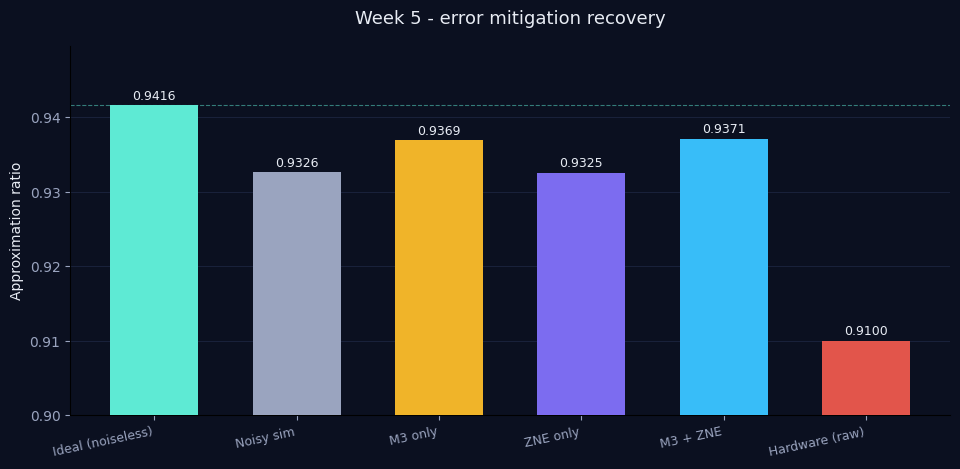

In [8]:
import matplotlib.pyplot as plt, os
HARDWARE_RAW = 0.910

rows = [("Ideal (noiseless)", ideal_ratio, "#5eead4"),
        ("Noisy sim",          noisy_ratio, "#9AA4BF"),
        ("M3 only",            m3_ratio,    "#f0b429"),
        ("ZNE only",           zne_ratio,   "#7c6cf0"),
        ("M3 + ZNE",           layered_ratio,"#38bdf8"),
        ("Hardware (raw)",     HARDWARE_RAW,"#e2554b")]
print(f"{'stage':22s} ratio    gap-to-ideal")
for name, r, _ in rows:
    print(f"{name:22s} {r:.4f}   {100*(ideal_ratio-r):+.2f} pp")

plt.rcParams.update({'font.family':'DejaVu Sans','figure.facecolor':'#0B1020','axes.facecolor':'#0B1020',
                     'text.color':'#E8ECF4','xtick.color':'#9AA4BF','ytick.color':'#9AA4BF','axes.labelcolor':'#E8ECF4'})
fig, ax = plt.subplots(figsize=(10,5.6)); fig.subplots_adjust(left=0.09,right=0.97,top=0.86,bottom=0.2)
names=[r[0] for r in rows]; vals=[r[1] for r in rows]; cols=[r[2] for r in rows]
bars=ax.bar(names, vals, color=cols, width=0.62, zorder=3)
ax.axhline(ideal_ratio, color='#5eead4', ls='--', lw=0.8, alpha=0.5, zorder=2)
ax.set_ylim(min(vals)-0.01, max(max(vals), ideal_ratio)+0.008)
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.0008, f"{v:.4f}", ha='center', fontsize=9)
ax.set_ylabel("Approximation ratio"); ax.set_title("Week 5 - error mitigation recovery", fontsize=13, pad=16)
ax.grid(axis='y', color='#1c2540', lw=0.6, zorder=0)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.xticks(rotation=12, ha='right', fontsize=9)
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/week5_mitigation.png', dpi=200, facecolor='#0B1020', bbox_inches='tight')
print("saved figures/week5_mitigation.png")

## Section 7 — Hardware run
Flip `RUN_HARDWARE = True`. Path A mirrors this notebook (Sampler -> counts -> M3, then manual ZNE). Path B is the production route (EstimatorV2 resilience handles ZNE + readout internally on the cost Hamiltonian). Verify the backend/session setup against your working Week 3 code.

In [9]:
if RUN_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)   # or your Week 3 backend
    isa = transpile(qaoa_ansatz.copy(), backend); isa.measure_all()
    try:    meas_qubits = list(isa.layout.final_index_layout())
    except Exception: meas_qubits = physical_qubits
    hw_mit = mthree.M3Mitigation(backend)
    hw_mit.cals_from_system(meas_qubits)
    job = SamplerV2(backend).run([isa], shots=SHOTS)
    hw_counts = job.result()[0].data.meas.get_counts()
    hw_quasi  = hw_mit.apply_correction(hw_counts, meas_qubits)
    hw_m3 = approx_ratio(sum(cost_bitstring(b)*p for b, p in hw_quasi.items()))
    print(f"hardware M3 ratio = {hw_m3:.4f}")
    # PATH B (production): EstimatorV2 resilience on the cost Hamiltonian (SparsePauliOp)
    # from qiskit_ibm_runtime import EstimatorV2
    # est = EstimatorV2(backend)
    # est.options.resilience_level = 2                # ZNE on
    # est.options.resilience.measure_mitigation = True
    # res = est.run([(isa_no_meas, cost_hamiltonian)]).result()
else:
    print("RUN_HARDWARE = False - sim validation only")

RUN_HARDWARE = False - sim validation only


## Reading the result per channel

- **M3 recovery** measures your **readout** channel directly. If M3 alone recovers most of the gap, readout was your dominant error (as the Week 4 sim said).
- **ZNE recovery** measures the **gate** channel. Trust it only if the Section 4 scale curve sloped downward; a flat curve means ZNE has no signal and any apparent recovery is variance.
- **The gap that survives M3 + ZNE** is the un-mitigable residual: coherent SWAP-routing error and crosstalk that neither technique removes. On hardware this is expected to be sizeable (the sim's 0.78pp vs the real 3.40pp) and is the honest Week 5 finding, not an engineering failure.